In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output   #jupyter animation

import os
os.makedirs("snapshots_data", exist_ok=True)

1. Define lattice setup

In [171]:
L = 16  
num_species = 4
total_sites = L * L
temperature = 1.0
steps = 100001

2. Create an equal distribution of components and shuffle

In [172]:
arrangement = np.repeat(np.arange(num_species), total_sites // num_species)
np.random.shuffle(arrangement)
lattice = arrangement.reshape((L, L))

3. Function to calculate the total energy of a configuration

In [173]:
# A symmetric 4x4 energy lookup matrix
energy_matrix = np.array([
    [ 0.0, -2.0,  0.5,  0.1],  # Interactions for Atom 0
    [-2.0,  0.0,  0.2,  0.8],  # Interactions for Atom 1
    [ 0.5,  0.2,  0.0,  1.5],  # Interactions for Atom 2
    [ 0.1,  0.8,  1.5,  0.0]   # Interactions for Atom 3
])

In [174]:
def calculate_total_energy(lattice, energy_matrix):
    """
    Calculates total energy where every atom pair configuration 
    has a specific energy defined in energy_matrix.
    """
    # Grab the right and down neighbors using our periodic wrapping
    right_neighbors = np.roll(lattice, shift=-1, axis=1)
    down_neighbors = np.roll(lattice, shift=-1, axis=0)
    
    # Advanced NumPy indexing:
    # energy_matrix[lattice, right_neighbors] creates a 2D array of the same shape
    # as our lattice, where each pixel contains the exact pair energy value.
    bonds_right = energy_matrix[lattice, right_neighbors]
    bonds_down = energy_matrix[lattice, down_neighbors]
    
    # Sum up all the mapped energies
    total_energy = np.sum(bonds_right) + np.sum(bonds_down)
    return float(total_energy)

initial_energy = calculate_total_energy(lattice, energy_matrix)
print(initial_energy)

52.9


4. Metropolis step (swap neighbors and accept or reject based on canonical Metropolis)

In [175]:
DIRECTIONS = np.array([
    [-1,  0],  # Up
    [ 1,  0],  # Down
    [ 0, -1],  # Left
    [ 0,  1]   # Right
])

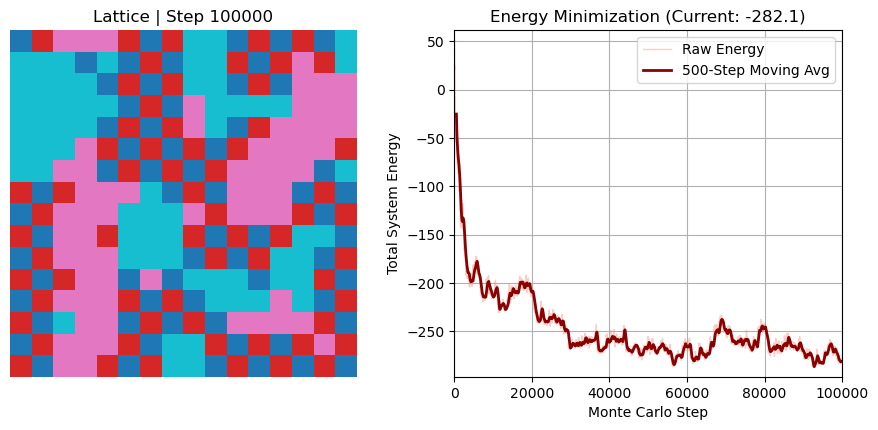

[!] Final plot saved to 'energy_equilibration.png'


In [177]:
history_steps = []
history_energy = []

window_size = 500

# --- 2. Set Up the Double-Panel Figure ---
fig, (ax_grid, ax_energy) = plt.subplots(1, 2, figsize=(11, 4.5))
cmap_clean = plt.colormaps['tab10'].resampled(num_species)

# Left Panel: Grid
im = ax_grid.imshow(lattice, cmap=cmap_clean, vmin=0, vmax=num_species-1)
ax_grid.axis('off')

# Right Panel: Dual Lines (Raw Energy & Moving Average)
line_raw, = ax_energy.plot([], [], color='salmon', alpha=0.4, label='Raw Energy', lw=1)
line_ma, = ax_energy.plot([], [], color='darkred', label=f'{window_size}-Step Moving Avg', lw=2)
ax_energy.set_xlabel("Monte Carlo Step")
ax_energy.set_ylabel("Total System Energy")
ax_energy.grid(True)
ax_energy.legend(loc='upper right')

E_current = calculate_total_energy(lattice, energy_matrix)

# --- 3. Metropolis Loop ---
for step in range(steps):
    coord_1 = np.random.randint(0, L, size=2)
    shift = DIRECTIONS[np.random.randint(0, 4)]
    coord_2 = (coord_1 + shift) % L
    
    i1, j1 = coord_1
    i2, j2 = coord_2
    
    # Propose swap
    lattice[i1, j1], lattice[i2, j2] = lattice[i2, j2], lattice[i1, j1]
    E_proposed = calculate_total_energy(lattice, energy_matrix)
    dE = E_proposed - E_current
    
    if dE <= 0 or np.random.rand() < np.exp(-dE / temperature):
        E_current = E_proposed
    else:
        lattice[i1, j1], lattice[i2, j2] = lattice[i2, j2], lattice[i1, j1]
        
    history_steps.append(step)
    history_energy.append(E_current)
        
    # Visual updates
    if step % 50 == 0 or step == steps - 1:
        # Update lattice image
        im.set_data(lattice)
        ax_grid.set_title(f"Lattice | Step {step}")
        
        # Calculate moving average using standard 1D convolution
        if len(history_energy) >= window_size:
            # Create a uniform window for the rolling mean
            weights = np.ones(window_size) / window_size
            ma_values = np.convolve(history_energy, weights, mode='valid')
            # The 'valid' mode shifts indices by (window_size - 1)
            ma_steps = history_steps[window_size - 1:]
            
            line_ma.set_data(ma_steps, ma_values)
        
        # Update raw energy line
        line_raw.set_data(history_steps, history_energy)
        
        # Adjust axes view limits dynamically
        ax_energy.set_xlim(0, max(10, step))
        ax_energy.set_ylim(min(history_energy) - 10, max(history_energy) + 10)
        ax_energy.set_title(f"Energy Minimization (Current: {E_current:.1f})")
        
        display(fig, clear=True)
        time.sleep(0.01)

# --- 4. Save and Close ---
# Save the final rendered state of both plots to disk before closing the loop
fig.savefig("energy_equilibration.png", dpi=300, bbox_inches='tight')
print("[!] Final plot saved to 'energy_equilibration.png'")

plt.close(fig)